# Housekeeping

In [1]:
# Load libs
import os
import pickle
import re
import time
import warnings

from pathlib import Path

import lseg.data as ld
import pandas as pd
import matplotlib.pyplot as plt

print("Kernel PID:", os.getpid())

Kernel PID: 3448


In [2]:
#### Initialize LSEG
ld.open_session()

##### Store current directory
curr_dir = Path(os.getcwd())

# Everything this notebook pulls from LSEG is a RAW extract, so it all lands under data/0_raw/.
# No downstream notebook ever writes here - 01 reads these and writes to data/1_preprocessed.
data_dir = curr_dir / "data"
raw_dir = data_dir / "0_raw"

# Stock-level extracts, plus the .csv mirrors of the index/bond series pulled below.
stocks_dir = raw_dir / "stocks"
stocks_dir.mkdir(parents=True, exist_ok=True)

# CDAX index-level extracts (membership, static info, price/value series).
cdax_dir = raw_dir / "cdax"
cdax_dir.mkdir(parents=True, exist_ok=True)

# Resume checkpoints for the chunked LSEG fetches - large, slow, and restartable.
checkpoints_dir = raw_dir / "checkpoints"
checkpoints_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Surpresses a FutureWarning that is specifically caused by LSEG API, leads to vast outputs making it harder to navigate outputs
# Retrieved the specific module tha causes the future warning using Claude.ai

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"lseg\.data\._tools\._dataframe",
)

In [4]:
# Set Date range
# GLOBAL_SDATE = "1993-12-31"  # CDAX commenced September 17, 1993 (with back-calculated historical data to 1970)
GLOBAL_SDATE = "1998-04-03" # Earliest date LSEG provides Joiner/Leaver events which are needed for membership history
GLOBAL_EDATE = "2026-04-30" # Latest available Joiner Leaver Date LSEG provides

## Playground

In [5]:
t0 = time.time()
test_ric = ld.get_history(
    universe="ADNGk.DE",  #'DE10YT=RR',
    fields="TR.TotalReturn",
    interval="daily",
    start=GLOBAL_SDATE,  
    end=GLOBAL_EDATE,  
    parameters={"CURN": "EUR"},
)
t1 = time.time()
print(test_ric)
print(f"{t1 - t0}s")

ADNGk.DE    Total Return
Date                    
2000-06-21           0.0
2000-06-22       2.92599
2000-06-23     23.745819
2000-06-26     -8.378378
2000-06-27      0.943953
...                  ...
2026-04-24      0.509338
2026-04-27     -0.337838
2026-04-28     -1.355932
2026-04-29      0.515464
2026-04-30      -0.34188

[5801 rows x 1 columns]
5.2439124584198s


In [6]:
# GLOBAL_SDATE = "2001-12-31"
# GLOBAL_SDATE = "2025-06-30"

test = ld.get_data(
    universe=[".CDAX"],
    fields=[
        "TR.IndexJLConstituentChangeDate",
        "TR.IndexJLConstituentRIC",
        "TR.IndexJLConstituentName",
        "TR.IndexJLConstituentComName",
        "TR.IndexJLConstituentituentChange", # Wrong spelling is correct!
    ],
    parameters={"SDate": GLOBAL_SDATE, "EDate": GLOBAL_EDATE, "IC": "B"},
)

test

,Instrument,Date,Constituent RIC,Constituent Name,Constituent Common Name,Change
0,.CDAX,1998-04-03,FMEG_p.F^G13,Fresenius Med Cr,Fresenius Medical Care AG,Joiner
1,.CDAX,1998-04-03,HISG.F^G02,HIS Sportswear,HIS Sportswear AG,Joiner
2,.CDAX,1998-04-03,DPFG.F^B05,DEPFA Deutsche,DEPFA Deutsche Pfandbriefbank AG,Joiner
3,.CDAX,1998-04-03,STAG_p.F^K01,Stada Arzneimitt,STADA Arzneimittel AG,Joiner
4,.CDAX,1998-04-03,KPGG.F^J07,Rheinmetall Auto,Rheinmetall Automotive AG,Joiner
...,...,...,...,...,...,...
2442,.CDAX,2025-09-22,PTHH.F,Path2 Hydrogen,Path2 Hydrogen AG,Leaver
2443,.CDAX,2025-12-22,TKMS.DE,TKMS,TKMS AG & Co KgaA,Joiner
2444,.CDAX,2025-12-22,OBCK.DE,Ottobock,Ottobock SE & Co KgaA,Joiner
2445,.CDAX,2026-03-23,V1NC.DE,Vincorion,Vincorion Se,Joiner


In [7]:
test_c = ld.get_data('0#.CDAX', 
                     fields=['TR.IndexConstituentRIC', 'TR.CommonName'],
                     parameters={"SDate": GLOBAL_SDATE, "EDate": GLOBAL_EDATE})

test_c

,Instrument,Constituent RIC,Company Common Name
0,EVKn.DE,,Evonik Industries AG
1,BNRGn.DE,,Brenntag SE
2,NOEJ.DE,,Norma Group SE
3,JST.DE,,Jost Werke SE
4,ZILGn.DE,,ElringKlinger AG
...,...,...,...
316,MTXGn.DE,,MTU Aero Engines AG
317,UUUG.DE,,3U Holding AG
318,EUZG.DE,,Eckert & Ziegler SE
319,V1NC.DE,,Vincorion Se


# Membership History & Static data

## Create membership matrix

In [5]:
start = time.time()
# Get Joiner and Leaver for CDAX from Start- to End-date
df_changes = ld.get_data(
    universe=[".CDAX"],
    fields=[
        "TR.IndexJLConstituentChangeDate",
        "TR.IndexJLConstituentRIC",
        "TR.IndexJLConstituentName",
        "TR.IndexJLConstituentComName",
        "TR.IndexJLConstituentituentChange", # Wrong spelling is correct!
    ],
    parameters={"SDate": GLOBAL_SDATE, "EDate": GLOBAL_EDATE, "IC": "B"},
)

print(f"\nTotal Events: # {len(df_changes)}")
print("Column names:", df_changes.columns.tolist())

# save events to csv
df_changes.to_csv(cdax_dir / f"cdax_events_as_of_{GLOBAL_EDATE}.csv")
df_changes.to_parquet(cdax_dir / f"cdax_events_as_of_{GLOBAL_EDATE}.parquet")
df_changes


Total Events: # 2447
Column names: ['Instrument', 'Date', 'Constituent RIC', 'Constituent Name', 'Constituent Common Name', 'Change']


,Instrument,Date,Constituent RIC,Constituent Name,Constituent Common Name,Change
0,.CDAX,1998-04-03,NEWG.F^F03,Neckarwerke,Neckarwerke Stuttgart GmbH,Joiner
1,.CDAX,1998-04-03,JUNG_p.F,Jungheinrich,Jungheinrich AG,Joiner
2,.CDAX,1998-04-03,DRSDn.F^G02,Dresdner Bk,Dresdner Bank AG,Joiner
3,.CDAX,1998-04-03,SAIGe.F^B00,Sai Automotive,Sai Automotive AG,Joiner
4,.CDAX,1998-04-03,SNCG_p.DE^E11,Sanacorp Pharma,Sanacorp Pharmaholding AG,Joiner
...,...,...,...,...,...,...
2442,.CDAX,2025-09-22,P4OG.DE,Plan Optik,Plan Optik AG,Joiner
2443,.CDAX,2025-12-22,TKMS.DE,TKMS,TKMS AG & Co KgaA,Joiner
2444,.CDAX,2025-12-22,OBCK.DE,Ottobock,Ottobock SE & Co KgaA,Joiner
2445,.CDAX,2026-03-23,V1NC.DE,Vincorion,Vincorion Se,Joiner


In [6]:
start = time.time()
# Static (current) fields: one row per RIC, no time dimension
all_rics = list(df_changes["Constituent RIC"].unique())

static_fields = [
    "TR.CommonName",
    'TR.RIC',
    "TR.ISIN",
    "TR.OrganizationID",
    "TR.CountryOfHeadquarters",
    "TR.ExchangeName",
    "TR.AssetTypeName",
    "TR.TRBCEconomicSector",
    "TR.TRBCBusinessSector",
    # "TR.GICSSector", # Not maintained properly
    # "TR.GICSIndustryGroup", # Not maintained properly
    "TR.IssueListingDate",
    "TR.IsDelistedQuote",
]


# Static data can handle larger chunks (no time series expansion)
def pull_static(ids):
    return ld.get_data(universe=ids, fields=static_fields)

chunk_size = 200
static_chunks = [all_rics[i : i + chunk_size] for i in range(0, len(all_rics), chunk_size)]
static_results = []

for i, ch in enumerate(static_chunks):
    try:
        static_results.append(pull_static(ch))
        print(f"Static {i + 1}/{len(static_chunks)} OK")
    except Exception as e:
        print(f"Static {i + 1} failed: {e}")
    time.sleep(0.05)

static_df = pd.concat(static_results, ignore_index=True)
static_df = static_df.drop(columns=["Instrument"])

# Exclude all stocks not listed at Xetra or Frankfurt Stock Exchange
# Both are needed, e.g. Covestro is part of CDAX but only has FSE listing, no Xetra listing.
static_df_xetra = static_df[static_df["Exchange Name"].isin(["Xetra", "Frankfurt Stock Exchange"])].copy()
all_rics_xetra = list(set(static_df_xetra["RIC"]))
all_isin_xetra = list(set(static_df_xetra["ISIN"]))

# Export
# static_df.to_parquet(cdax_dir / f"cdax_static_info_as_of_{GLOBAL_EDATE}.parquet")
# static_df.to_csv(cdax_dir / f"cdax_static_info_as_of_{GLOBAL_EDATE}.csv")

static_df_xetra.to_parquet(cdax_dir / f"cdax_static_info_xetra_as_of_{GLOBAL_EDATE}.parquet")
static_df_xetra.to_csv(cdax_dir / f"cdax_static_info_xetra_as_of_{GLOBAL_EDATE}.csv")

end = time.time()

print(
    f"Unique RICs: {len(all_rics)} \nUnique ISINs: {len(all_isin_xetra)} \nUnique RICs (Xetra-only): {len(all_rics_xetra)} \nDuration: {end - start:.2f}s"
)

Static 1/8 OK
Static 2/8 OK
Static 3/8 OK
Static 4/8 OK
Static 5/8 OK
Static 6/8 OK
Static 7/8 OK
Static 8/8 OK
Unique RICs: 1557 
Unique ISINs: 1186 
Unique RICs (Xetra-only): 1546 
Duration: 108.50s


In [7]:
requested = set(all_rics)
with_static = set(static_df["RIC"].dropna())
kept = set(static_df_xetra["RIC"].dropna())

print(f"RICs requested            : {len(requested)}")
print(f"RICs with no static row   : {len(requested - with_static)}")
print(f"RICs cut by exchange filter: {len(with_static - kept)}")
print()

removed = static_df[~static_df["RIC"].isin(kept)]
print("Exchange names that were filtered out:")
print(removed["Exchange Name"].value_counts(dropna=False))

RICs requested            : 1557
RICs with no static row   : 0
RICs cut by exchange filter: 11

Exchange names that were filtered out:
Exchange Name
                           4
London Stock Exchange      2
Berlin Stock Exchange      2
USA Pink Sheets            1
Warsaw Stock Exchange      1
New York Stock Exchange    1
Name: count, dtype: Int64


In [11]:
# Print number of rows where mapping ISIN is null and where mapping Organizational PermID is null
isin_null_count = static_df_xetra["ISIN"].isna().sum()
isin_null_pct = (isin_null_count / len(static_df_xetra)) * 100 if len(static_df_xetra) else 0
print(f"Rows with null mapped ISIN ({isin_null_count}): {isin_null_count} ({isin_null_pct:.2f}%)")

static_df_xetra[static_df_xetra["ISIN"].isna()]

Rows with null mapped ISIN (0): 0 (0.00%)


,Company Common Name,RIC,ISIN,Organization PermID,Exchange Name,TRBC Economic Sector Name,TRBC Business Sector Name,Delisted Quote Flag


In [8]:
# Merge ISIN on df_changes to map to current companies
df_changes = df_changes.merge(
    static_df_xetra[["RIC", "ISIN"]],
    how="left",
    left_on="Constituent RIC",
    right_on="RIC",
    suffixes=("", "_mapped"),
).drop(
    columns=["RIC"]
)

In [13]:
# Print number of rows where mapping ISIN is null
isin_null_count = df_changes["ISIN"].isna().sum()
isin_null_pct = (isin_null_count / len(df_changes)) * 100 if len(df_changes) else 0
print(f"Rows with null mapped ISIN ({isin_null_count}): {isin_null_count} ({isin_null_pct:.2f}%)")

df_changes[df_changes["ISIN"].isna()]

Rows with null mapped ISIN (16): 16 (0.65%)


,Instrument,Date,Constituent RIC,Constituent Name,Constituent Common Name,Change,ISIN
28,.CDAX,1998-04-03,WFVG.F^I99,Wuestenrot & Wrt,Wuestenrot & Wuerttembergische AG,Joiner,<NA>
275,.CDAX,1998-04-03,DBCG.F^G01,Babcock Borsig,Babcock Borsig AG,Joiner,<NA>
451,.CDAX,1998-10-01,FBEG.F^G99,ELEKTRA BECKUM,Elektra Beckum AG,Joiner,<NA>
486,.CDAX,1998-10-01,PBFI.PK^E03,Paris Corp,Paris Corp,Joiner,<NA>
684,.CDAX,1999-11-01,FBEG.F^G99,ELEKTRA BECKUM,Elektra Beckum AG,Leaver,<NA>
936,.CDAX,2001-07-16,DBCG.DE^G01,Babcock Borsig,Babcock Borsig AG,Leaver,<NA>
2052,.CDAX,2015-09-25,IOIGEUR.Lp^I15,Ision Internet,ISION Internet AG,Joiner,<NA>
2053,.CDAX,2015-09-28,IOIGEUR.Lp^I15,Ision Internet,ISION Internet AG,Leaver,<NA>
2127,.CDAX,2016-12-20,0QEY.L^L16,Pacific Retail,Pacific Retail Merchants AG,Joiner,<NA>
2128,.CDAX,2016-12-20,0QEY.L^L16,Pacific Retail,Pacific Retail Merchants AG,Leaver,<NA>


In [9]:
# How many event rows lose their ISIN in the RIC -> ISIN mapping?
missing = df_changes["ISIN"].isna()

print(f"Event rows total         : {len(df_changes)}")
print(f"Rows without ISIN        : {missing.sum()}")
print(f"Unique RICs without ISIN : {df_changes.loc[missing, 'Constituent RIC'].nunique()}")
print()

# A big Joiner/Leaver imbalance here is the warning sign
print("Dropped rows by change type:")
print(df_changes.loc[missing, "Change"].value_counts())
print()

if missing.sum() > 0:
    dropped_dates = pd.to_datetime(df_changes.loc[missing, "Date"], errors="coerce")
    print("Dropped events per year:")
    print(dropped_dates.dt.year.value_counts().sort_index())

Event rows total         : 2447
Rows without ISIN        : 16
Unique RICs without ISIN : 11

Dropped rows by change type:
Change
Joiner    10
Leaver     6
Name: count, dtype: Int64

Dropped events per year:
Date
1998    4
1999    1
2001    1
2015    2
2016    2
2019    1
2021    2
2022    2
2024    1
Name: count, dtype: int64


In [15]:
# Filter out rows where ISIN is null, as these are not mappable to current companies
df_changes = df_changes[df_changes["ISIN"].notna()].copy()
static_df_xetra = static_df_xetra[static_df_xetra["ISIN"].notna()].copy()

In [10]:
# Get current CDAX constituents (free-float volumne weighted index)
current = ld.get_data(
    universe=["0#.CDAX"],
    fields=["TR.RIC", 'TR.ISIN', "TR.OrganizationID", 'TR.CommonName'],
)

current_ISIN = set(current["ISIN"].dropna().unique())  # Today
current_RIC = set(current["RIC"].dropna().unique())  # Today

print(f"# Current Constituents: {len(current_ISIN)} RICs / {len(current_RIC)} ISINs")


# Merge current ISIN on df_changes to for a check
current_merge = current.merge(
    df_changes[["Constituent RIC", "ISIN"]],
    how="left",
    left_on="RIC",
    right_on="Constituent RIC",
    suffixes=("", "_current"),
)

print(f"Nb: Merged ISIN {len(current_merge['ISIN'].dropna().unique())}/{len(current_ISIN)}")

# Current Constituents: 320 RICs / 320 ISINs
Nb: Merged ISIN 320/320


In [11]:

# Merge current ISIN on df_changes to for a check
df_changes = df_changes.merge(
    current[["RIC", "ISIN"]],
    how="left",
    left_on="ISIN",
    right_on="ISIN",
    suffixes=("", "_current"),
)

print(f"Nb. of RICs from current CDAX constituents: {len(df_changes['RIC'].dropna().unique())}/{len(current_RIC)}")
df_changes

Nb. of RICs from current CDAX constituents: 317/320


,Instrument,Date,Constituent RIC,Constituent Name,Constituent Common Name,Change,ISIN,RIC
0,.CDAX,1998-04-03,NEWG.F^F03,Neckarwerke,Neckarwerke Stuttgart GmbH,Joiner,DE0006758006,<NA>
1,.CDAX,1998-04-03,JUNG_p.F,Jungheinrich,Jungheinrich AG,Joiner,DE0006219934,JUNG_p.DE
2,.CDAX,1998-04-03,DRSDn.F^G02,Dresdner Bk,Dresdner Bank AG,Joiner,DE0005350003,<NA>
3,.CDAX,1998-04-03,SAIGe.F^B00,Sai Automotive,Sai Automotive AG,Joiner,DE0005009013,<NA>
4,.CDAX,1998-04-03,SNCG_p.DE^E11,Sanacorp Pharma,Sanacorp Pharmaholding AG,Joiner,DE000A2BPP70,<NA>
...,...,...,...,...,...,...,...,...
2442,.CDAX,2025-09-22,P4OG.DE,Plan Optik,Plan Optik AG,Joiner,DE000A0HGQS8,P4OG.DE
2443,.CDAX,2025-12-22,TKMS.DE,TKMS,TKMS AG & Co KgaA,Joiner,DE000TKMS001,TKMS.DE
2444,.CDAX,2025-12-22,OBCK.DE,Ottobock,Ottobock SE & Co KgaA,Joiner,DE000BCK2223,OBCK.DE
2445,.CDAX,2026-03-23,V1NC.DE,Vincorion,Vincorion Se,Joiner,DE000VNC0014,V1NC.DE


In [12]:
start = time.time()

# Needed for RIC
def clean_id(col: pd.Series) -> pd.Series:
    s = col.astype(str).str.strip()
    return s.mask(col.isna() | s.eq("") | s.str.lower().eq("nan"))

# Rename and convert datatypes of cols
events = pd.DataFrame(
    {
        "date": pd.to_datetime(df_changes["Date"], errors="coerce"),
        "ric": clean_id(df_changes["Constituent RIC"]),
        "ISIN": clean_id(df_changes["ISIN"]),
        "type": df_changes["Change"].astype(str).str.strip(),
    }
)

missing_isin = events["ISIN"].isna() & events["date"].notna()
print(f"Events missing ISIN: {missing_isin.sum()} ",
      f"(Joiner={ (missing_isin & events['type'].eq('Joiner')).sum() }, ",
      f"Leaver={ (missing_isin & events['type'].eq('Leaver')).sum() })")

events = events.dropna(subset=["date", "ISIN", "type"])

# Backfill using snapshot form end-date and joiner/leaver events
state = current_ISIN.copy()
today = pd.Timestamp.today().normalize()
snapshots = {today: state.copy()}
grouped = events.groupby("date")

for date in sorted(grouped.groups.keys(), reverse=True):
    snapshots[date] = state.copy()
    day = grouped.get_group(date)
    joiners = set(day.loc[day["type"] == "Joiner", "ISIN"])
    leavers = set(day.loc[day["type"] == "Leaver", "ISIN"])
    state -= joiners
    state |= leavers

snapshots[pd.Timestamp(GLOBAL_SDATE)] = state.copy()
print(f"\nSnapshots: # {len(snapshots)}")
print(f"Initial Constituents as of {GLOBAL_SDATE}: # {len(state)}")

# Create Wide and Long DataFrame
rows = [{"date": d, "ric": r} for d, members in snapshots.items() for r in members]
snapshot_long = pd.DataFrame(rows)

snapshot_wide = (
    snapshot_long.assign(member=1)
    .pivot_table(index="date", columns="ric", values="member", fill_value=0)
    .astype("int8")
    .sort_index()
)
print(f"\nUnique RICs: # {snapshot_wide.shape[1]}")

# Sample daily and quarterly (month-end) and quarterly
daily_range = pd.date_range(
    start=snapshot_wide.index.min(),
    end=today,
    freq="D",
)

daily = (
    snapshot_wide.reindex(snapshot_wide.index.union(daily_range))
    .sort_index()
    .ffill()
    .fillna(0)
    .loc[daily_range]
    .astype("int8")
)

daily.index.name = "Date"

# Monthly version
monthly = daily.resample("ME").last()
monthly.index.name = "Date"

# Quarterly version
quarterly = daily.resample("QE").last()
quarterly.index.name = "Date"

# Sanity-Checks & Print
counts_daily = daily.sum(axis=1)
counts_monthly = monthly.sum(axis=1)
counts_quarterly = quarterly.sum(axis=1)

print("\n Sanity-Checks:")
print(
    f"Daily: min={counts_daily.min()}, median={counts_daily.median():.0f}, max={counts_daily.max()}"
)

print(
    f"Monthly: min={counts_monthly.min()}, "
    f"median={counts_monthly.median():.0f}, "
    f"max={counts_monthly.max()}"
)

print(
    f"Quarterly: min={counts_quarterly.min()}, "
    f"median={counts_quarterly.median():.0f}, "
    f"max={counts_quarterly.max()}"
)

print(f"Daily:   {daily.shape[0]} Days x {daily.shape[1]} RICs")
print(f"Monthly: {monthly.shape[0]} Months x {monthly.shape[1]} RICs")
print(f"Quarterly: {quarterly.shape[0]} Quarters x {quarterly.shape[1]} RICs")

last_state = set(monthly.columns[monthly.iloc[-1] == 1])
diff = current_ISIN ^ last_state
print(f"Diff current vs. last month: {len(diff)} RICs")

joiner_ISIN = set(events.loc[events["type"] == "Joiner", "ISIN"])
leaver_ISIN = set(events.loc[events["type"] == "Leaver", "ISIN"])

print(f"Unique Joiner-ISINs: {len(joiner_ISIN)}")
print(f"Unique Leaver-ISINs: {len(leaver_ISIN)}")
print(f"Intersection:       {len(joiner_ISIN & leaver_ISIN)}")
print(f"Only joined:        {len(joiner_ISIN - leaver_ISIN)}")
print(f"Only left:          {len(leaver_ISIN - joiner_ISIN)}")

# Save and export
daily.to_parquet(cdax_dir / 'cdax_membership_daily.parquet')
monthly.to_parquet(cdax_dir / 'cdax_membership_monthly.parquet')
quarterly.to_parquet(cdax_dir / 'cdax_membership_quarterly.parquet')

daily.to_csv(cdax_dir / 'cdax_membership_daily.csv')
monthly.to_csv(cdax_dir / 'cdax_membership_monthly.csv')
quarterly.to_csv(cdax_dir / 'cdax_membership_quarterly.csv')

print("\nSaved: cdax_membership_daily.parquet, cdax_membership_monthly.parquet, cdax_membership_quarterly.parquet")

all_rics = monthly.columns.tolist()
print(f"RICs to pull: {len(all_rics)}")

end = time.time()
print(f"Duration: {end - start:.2f}s")

Events missing ISIN: 18  (Joiner=11,  Leaver=7)

Snapshots: # 1136
Initial Constituents as of 1998-04-03: # 7

Unique RICs: # 1171

 Sanity-Checks:
Daily: min=7, median=502, max=786
Monthly: min=317, median=501, max=786
Quarterly: min=318, median=498, max=786
Daily:   10368 Days x 1171 RICs
Monthly: 341 Months x 1171 RICs
Quarterly: 114 Quarters x 1171 RICs
Diff current vs. last month: 0 RICs
Unique Joiner-ISINs: 1183
Unique Leaver-ISINs: 885
Intersection:       883
Only joined:        300
Only left:          2

Saved: cdax_membership_daily.parquet, cdax_membership_monthly.parquet, cdax_membership_quarterly.parquet
RICs to pull: 1171
Duration: 2.98s


In [13]:
# Rows where ISIN is missing, by type
missing = events["ISIN"].isna()
print(events.loc[missing, "type"].value_counts())

# Smoking gun: dates where a Leaver's RIC has a same-day Joiner with valid ISIN
raw = pd.DataFrame({
    "date": pd.to_datetime(df_changes["Date"], errors="coerce"),
    "ric": df_changes["Constituent RIC"].astype(str).str.strip(),
    "isin_raw": df_changes["ISIN"],
    "type": df_changes["Change"].astype(str).str.strip(),
})
missing_leaver_rics = set(raw.loc[raw["isin_raw"].isna() & raw["type"].eq("Leaver"), "ric"])
print(f"Leaver rows with missing ISIN: {len(missing_leaver_rics)}")

# Where do the big single-day net drops happen? (walk forward this time, chronological)
day_net = events.assign(
    delta=lambda d: d["type"].map({"Joiner": 1, "Leaver": -1})
).groupby("date")["delta"].sum().sort_index()
print("Biggest single day drops:\n",day_net.sort_values().head(15))   # biggest net removals — look at these dates

Series([], Name: count, dtype: int64)
Leaver rows with missing ISIN: 6
Biggest single day drops:
 date
2011-05-28   -93
2020-07-02    -9
2012-01-02    -7
2020-11-27    -5
2012-12-05    -5
2013-03-13    -4
2015-08-24    -4
2015-09-02    -4
2012-12-03    -4
2010-12-30    -4
2013-01-02    -4
2015-01-02    -3
2001-03-27    -3
2015-07-28    -3
2013-07-29    -3
Name: delta, dtype: int64


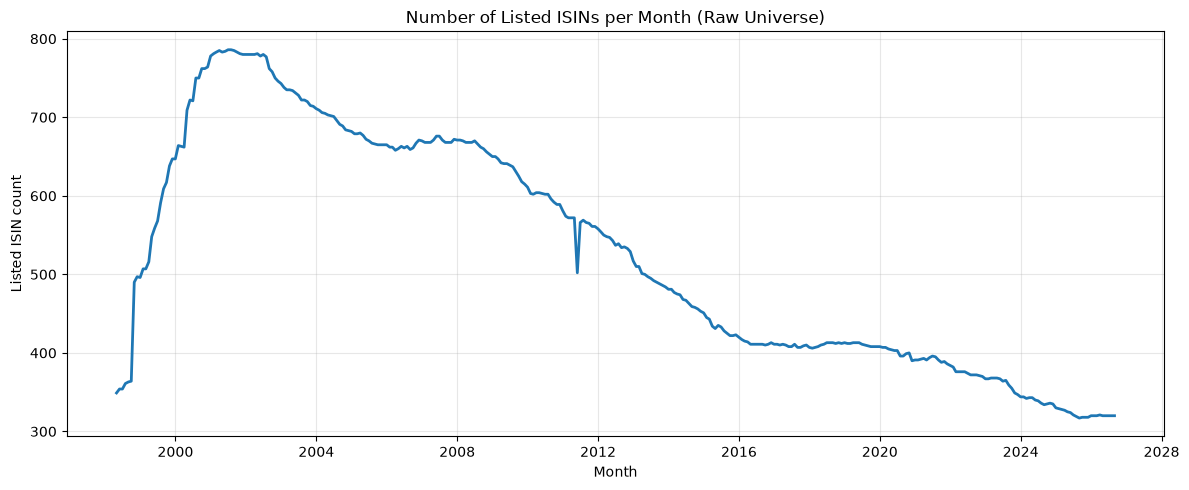

Plotted raw monthly ISIN history with 341 points from 1998-04-30 to 2026-08-31 (source: in-memory monthly).


In [14]:
# Plot RAW monthly RIC history (before Xetra filtering).
if "monthly" in globals():
    raw_monthly = monthly.copy()
    source_label = "in-memory monthly"
else:
    curr_dir = Path(os.getcwd())
    cdax_dir = curr_dir / "data" / "0_raw" / "cdax"

    raw_candidates = [
        cdax_dir / "cdax_membership_monthly.parquet",
        cdax_dir / "cdax_membership_monthly.csv",
    ]

    raw_source = next((p for p in raw_candidates if p.exists()), None)
    if raw_source is None:
        raise FileNotFoundError(
            "Could not find raw monthly membership file. Expected one of: "
            + ", ".join(str(p) for p in raw_candidates)
        )

    if raw_source.suffix == ".parquet":
        raw_monthly = pd.read_parquet(raw_source)
    else:
        raw_monthly = pd.read_csv(raw_source, index_col=0)

    source_label = raw_source.name

listed_per_month_raw = raw_monthly.fillna(0).astype(int).sum(axis=1)

if isinstance(listed_per_month_raw.index, pd.PeriodIndex):
    listed_per_month_raw.index = listed_per_month_raw.index.to_timestamp(how="end")
else:
    listed_per_month_raw.index = pd.to_datetime(listed_per_month_raw.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(listed_per_month_raw.index, listed_per_month_raw.values, linewidth=2)
ax.set_title("Number of Listed ISINs per Month (Raw Universe)")
ax.set_xlabel("Month")
ax.set_ylabel("Listed ISIN count")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Plotted raw monthly ISIN history with {len(listed_per_month_raw)} points "
    f"from {listed_per_month_raw.index.min().date()} to {listed_per_month_raw.index.max().date()} "
    f"(source: {source_label})."
)

# Define Functions

In [15]:
# Create functions to determine the start date for each, which helps to cut down on API requests
# Note: delisting is noted by the ^X00 methodoloy of LSEG in the ISIN of an instrument


def first_membership_date(membership_matrix):
    """First date at which each ISIN enters the index (first '1' per column).
    membership_matrix:
        DataFrame with a DatetimeIndex and one column per ISIN, values 1 (member) / 0 (non-member).
        NaN is treated as non-member.
    Returns:
        Series indexed by ISIN -> first membership date (pd.Timestamp).
        ISINs that are never members are omitted.
    """
    # Ensure clean boolean mask: 1/True -> member, everything else -> not.
    is_member = membership_matrix.fillna(0).astype(bool)

    # idxmax on a boolean frame returns the index label of the first True
    # per column. But idxmax also returns the first label when a column is
    # ALL False (it can't tell "no True" apart from "True at position 0"),
    # so we guard against never-member columns explicitly.
    first_dates = is_member.idxmax()  # first True per column which is sorted increasing, so first match is the oldest date, i.e. IPO date
    ever_member = is_member.any()  # True if column has any 1

    first_dates = first_dates[ever_member]  # drop never-member ISINs
    first_dates.name = "first_membership_date"
    # first_dates.index.name = "RIC"
    first_dates.index.name = "ISIN"

    return first_dates

# Not Required for ISIN
# Construct function to extract delisting date, in order to specify EDate for LSEG for each ISIN, instead of pulling data until global EDate in 2026
MONTH_MAP = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7,
    "H": 8,
    "I": 9,
    "J": 10,
    "K": 11,
    "L": 12,
}

# Only needed for RICs, not ISINs, as ISINs are unique and do not have the same delisting suffixes as RICs
def extract_delisting_date_ric(ric):
    """Parse the '^<Letter><YY>' suffix of a delisted RIC and return the
    delisting month-end as a pd.Timestamp. Returns None for active RICs.
    """
    match = re.search(r"\^([A-L])(\d{2})$", ric)
    if not match:
        return None

    month_letter, year_digits = match.groups()
    month = MONTH_MAP[month_letter]

    # Year heuristic: 00-30 -> 2000s, 31-99 -> 1900s
    year_int = int(year_digits)
    year = 2000 + year_int if year_int <= 30 else 1900 + year_int

    # Month-end as the delisting day (LSEG marks delistings at month granularity)
    first_of_month = pd.Timestamp(year=year, month=month, day=1)
    return first_of_month + pd.offsets.MonthEnd(0)





def extract_delisting_date(isin, leaver_dates):
    """Return the last date this ISIN left the index, or None if it never did.

    isin:         ISIN string, e.g. 'DE000A1H8MU2'
    leaver_dates: dict of ISIN -> date, built from the Leaver rows in `events`
    """
    if isin in leaver_dates:
        return leaver_dates[isin]
    else:
        return None


def get_effective_end_date(isin, leaver_dates, global_edate, buffer_months=1):
    """Return the earlier of (delisting date + buffer) and the global EDate
    as a pd.Timestamp. The buffer accounts for LSEG possibly still
    delivering data in the delisting month itself.
    """
    global_edate_ts = pd.Timestamp(global_edate)
    delisting = extract_delisting_date(isin, leaver_dates)

    if delisting is None:
        return global_edate_ts

    delisting_with_buffer = delisting + pd.DateOffset(months=buffer_months)
    return min(delisting_with_buffer, global_edate_ts)


# def _safe_filename(ric: str) -> str:
#     """Sanitise RIC for use as a filename ('^', '/', '.' are problematic)."""
#     return ric.replace("/", "_").replace("^", "X").replace(".", "_")


_CHUNK_YEARS_BY_INTERVAL = {
    "daily": 10,
    "weekly": 50,
    "monthly": None,  # None = no chunking, always fits in one call
    "quarterly": None,
    "yearly": None,
}


def build_date_ranges(
    membership_matrix, leaver_dates, global_edate, buffer_months=1, interval="daily"
):
    """
    Builds the control table for the API loop. Long date ranges are split into
    chunks based on the interval to stay within the 3,000-row per-request limit.

    Parameters:
        membership_matrix : pd.DataFrame
            DatetimeIndex x ISIN, values 1/0/NaN.
        leaver_dates : dict
            ISIN -> last Leaver date, built from the Leaver rows of `events`.
        global_edate : str | pd.Timestamp
            Global end date of the study, e.g. '2026-06-23'.
        buffer_months : int
            Buffer passed to get_effective_end_date() (default = 1).
        interval : str
            Data frequency: 'daily' | 'weekly' | 'monthly' | 'quarterly' | 'yearly'.
            Controls automatic chunk size to respect the 3,000-row API limit.

    Returns:
        pd.DataFrame
            MultiIndex ['ISIN', 'part'], columns ['chunk_start', 'chunk_end'].
            Single-chunk RICs will always have part=1.
    """
    if interval not in _CHUNK_YEARS_BY_INTERVAL:
        raise ValueError(
            f"Unsupported interval '{interval}'. Choose from: {list(_CHUNK_YEARS_BY_INTERVAL)}"
        )

    chunk_years = _CHUNK_YEARS_BY_INTERVAL[interval]
    first_dates = first_membership_date(membership_matrix)

    rows = []
    for isin, start in first_dates.items():
        end = get_effective_end_date(isin, leaver_dates, global_edate, buffer_months)

        if chunk_years is None:
            # No chunking needed — entire range fits in one request
            chunks = [(start, end)]
        else:
            chunks = []
            chunk_start = start
            while chunk_start < end:
                chunk_end = min(
                    pd.Timestamp(chunk_start + pd.DateOffset(years=chunk_years)),
                    end,
                )
                chunks.append((chunk_start, chunk_end))
                chunk_start = chunk_end + pd.Timedelta(1, unit="D")

        for part, (cs, ce) in enumerate(chunks, start=1):
            rows.append(
                {
                    "ISIN": isin,
                    "part": part,
                    "chunk_start": cs,
                    "chunk_end": ce,
                }
            )

    return pd.DataFrame(rows).set_index(["ISIN", "part"])


def fetch_all_histories(
    date_ranges,
    fields,
    interval="daily",
    parameters=None,
    sleep_sec=0.2,
    max_retries=3,
    checkpoint_path=checkpoints_dir / "results.pkl",
    checkpoint_every=50,
    output_path=stocks_dir / "all_histories.parquet",
):
    """
    Iterates over date_ranges and pulls data per (ISIN, part) chunk via get_timeseries().
    Checkpoints the results dict every N successful fetches.
    Concatenates all chunks per ISIN, then across ISINs, saves to parquet, and returns
    one concatenated DataFrame.

    Parameters:
        date_ranges      : pd.DataFrame   Output of build_date_ranges(); MultiIndex (ISIN, part).
        fields           : list[str]      LSEG field codes, e.g. ['TRDPRC_1', 'VOLUME'].
        interval         : str            'daily' | 'weekly' | 'monthly'.
        sleep_sec        : float          Pause between requests (rate limiting).
        max_retries      : int            Retry attempts per chunk on failure.
        checkpoint_path  : str | Path     Single pickle file for the full results dict.
        checkpoint_every : int            Persist checkpoint every N successful fetches.
        output_path      : str | Path     Final parquet output path.

    Returns:
        pd.DataFrame   MultiIndex (ISIN, Date), all successfully fetched histories.
        pd.DataFrame   MultiIndex (ISIN, Date), all successfully fetched histories.
    """

    t_start = time.time()

    ckpt_path = Path(checkpoint_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    # Resume: load checkpoint if it exists
    if ckpt_path.exists():
        with open(ckpt_path, "rb") as f:
            results = pickle.load(f)
        print(f"▶  Resumed: {len(results)}/{len(date_ranges)} chunks from checkpoint.\n")
    else:
        results = {}

    failed = []
    total = len(date_ranges)
    since_last_ckpt = 0
    isins_all = date_ranges.index.get_level_values("ISIN").unique()

    # Main fetch loop
    for i, ((isin, part), row) in enumerate(date_ranges.iterrows(), start=1):
        key = (isin, part)
        n_part = len(date_ranges.loc[isin])  # total chunks for this ISIN

        if key in results:
            print(f"[{i:>4}/{total}] {isin:<30}  part {part}/{n_part}  ✓ checkpoint")
            continue

        sdate = row["chunk_start"].strftime("%Y-%m-%d")
        edate = row["chunk_end"].strftime("%Y-%m-%d")
        print(f"[{i:>4}/{total}] {isin:<30}  part {part}/{n_part}  {sdate} → {edate}")

        for attempt in range(1, max_retries + 1):
            try:
                df = ld.get_history(
                    universe=isin,
                    fields=fields,
                    start=sdate,
                    end=edate,
                    interval=interval,
                    parameters=parameters,
                )

                results[key] = df
                since_last_ckpt += 1
                break

            except Exception as exc:
                print(f"         Attempt {attempt} failed: {exc}")
                if attempt < max_retries:
                    time.sleep(sleep_sec * attempt)  # exponential back-off
                else:
                    print(f"         ✗ Giving up: {isin} part {part}")
                    results[key] = None
                    failed.append(key)

        # Periodic checkpoint
        if since_last_ckpt >= checkpoint_every:
            with open(ckpt_path, "wb") as f:
                pickle.dump(results, f)
            print(f"         💾 Checkpoint saved ({len(results)} chunks so far)")
            since_last_ckpt = 0

        time.sleep(sleep_sec)

    # Final checkpoint
    with open(ckpt_path, "wb") as f:
        pickle.dump(results, f)

    # Summary
    n_ok_chunks = sum(1 for df in results.values() if df is not None)
    print(f"\n{'-' * 55}")
    print(f"  Total chunks fetched : {n_ok_chunks:>5}")
    print(f"  Chunks failed        : {len(failed):>5}")
    if failed:
        print(f"  Failed (ISIN, part)   : {failed}")
    print(f"{'-' * 55}\n")

    # Concatenate: stitch parts per ISIN, then stack all ISINs
    print("Concatenating results...")
    isin_dfs = {}
    for isin in isins_all:
        part_indices = date_ranges.loc[isin].index  # [1, 2, 3, ...]
        parts = [
            results[(isin, part)] for part in part_indices if results.get((isin, part)) is not None
        ]
        if parts:
            isin_dfs[isin] = pd.concat(parts)  # stitch chunks chronologically

    all_data = pd.concat(isin_dfs, names=["ISIN", "Date"])

    # Clean: replace empty strings with NaN, coerce numeric columns
    print("Cleaning data...")
    all_data = all_data.replace("", pd.NA)
    all_data = all_data.apply(pd.to_numeric, errors="coerce")

    # Save parquet
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    all_data.to_parquet(output_path)
    print(f"✓ Saved → '{output_path}'  ({all_data.shape[0]:,} rows × {all_data.shape[1]} cols)\n")

    # Save CSV (same path, .csv extension)
    all_data.to_csv(output_path.with_suffix(".csv"))
    print(f"✓ CSV saved    → '{output_path.with_suffix('.csv')}'\n")

    t_end = time.time()
    print(f"\n Duration: {t_end - t_start:.2f}s")
    return all_data, failed

In [16]:
# Build a lookup: ISIN -> the last date it left the index
# Sorting by date first means that when an ISIN appears several times, the later
# rows overwrite the earlier ones, so we end up keeping the most recent date.
leavers = events[events["type"] == "Leaver"]
leavers = leavers.sort_values("date")

leaver_dates = {}
for _, row in leavers.iterrows():
    leaver_dates[row["ISIN"]] = row["date"]

print(f"ISINs with a Leaver date: {len(leaver_dates)}")

# Quick check on a known delisted name (Adler Modemaerkte, RIC ADDG.F^H21)
print(f"DE000A1H8MU2 -> {leaver_dates.get('DE000A1H8MU2')}")


ISINs with a Leaver date: 885
DE000A1H8MU2 -> 2021-08-19 00:00:00


# Pull Data

## Daily

In [24]:
# Data pull for CDAX daily prices
start = time.time()

cdax_price_fields_daily = ["TR.PriceClose"]

df_cdax_daily_price = ld.get_history(
    universe=".CDAX",
    fields=cdax_price_fields_daily,
    interval="daily",
    start=GLOBAL_SDATE,
    end=GLOBAL_EDATE,
    parameters={"CURN": "EUR"},
)

df_cdax_daily_price.to_parquet(cdax_dir / "cdax_daily_price.parquet")
df_cdax_daily_price.to_csv(stocks_dir / "cdax_daily_price.csv")

end = time.time()
print(f"Duration: {end - start:.2f}s")

Duration: 5.80s


In [25]:
# Data pull for CDAX daily valuations
start = time.time()

cdax_value_fields_daily = [
    "TR.Index_PE_RTRS",
    "TR.Index_DIV_YLD_RTRS",
    "TR.Index_PRICE_TO_BOOK_RTRS",
    "TR.Index_MKT_CAP_RTRS",
]

df_cdax_daily_value = ld.get_history(
    universe=".CDAX",
    fields=cdax_value_fields_daily,
    interval="daily",
    start=GLOBAL_SDATE,
    end=GLOBAL_EDATE,
    parameters={"CURN": "EUR"},
)

df_cdax_daily_value.to_parquet(cdax_dir / "cdax_daily_value.parquet")
df_cdax_daily_value.to_csv(stocks_dir / "cdax_daily_value.csv")

end = time.time()
print(f"Duration: {end - start:.2f}s")

Duration: 8.30s


In [ ]:
# A few delisted ISINs plus two live ones as a control
delisted_isins = []
for isin in leaver_dates:
    if isin not in current_ISIN and isin in daily.columns:
        delisted_isins.append(isin)

sample_isins = delisted_isins[:5] + list(current_ISIN)[:2]
if "DE000A1H8MU2" in daily.columns and "DE000A1H8MU2" not in sample_isins:
    sample_isins = ["DE000A1H8MU2"] + sample_isins

print(f"Testing {len(sample_isins)} ISINs: {sample_isins}")

daily_sample = daily[sample_isins]

date_ranges_sample = build_date_ranges(
    daily_sample, leaver_dates, GLOBAL_EDATE, buffer_months=1, interval="daily"
)
print(date_ranges_sample)

stocks_sample, stocks_sample_failed = fetch_all_histories(
    date_ranges=date_ranges_sample,
    fields=["TR.PriceClose"],
    interval="daily",
    parameters={"CURN": "EUR"},
    sleep_sec=0.05,
    max_retries=2,
    checkpoint_path=checkpoints_dir / "ckpt_sample.pkl",
    checkpoint_every=50,
    output_path=stocks_dir / "sample_test.parquet",
)

rows_per_isin = stocks_sample.groupby(level="ISIN").size()
print(f"\nISINs requested: {len(sample_isins)}")
print(f"ISINs returned : {len(rows_per_isin)}")
print(rows_per_isin)
stock_sample

Testing 8 ISINs: ['DE000A1H8MU2', 'DE0007302002', 'DE0008000001', 'DE0007283038', 'DE0008078007', 'DE0008020009', 'DE000A1PHFF7', 'DE000ENAG999']
                  chunk_start  chunk_end
ISIN         part                       
DE000A1H8MU2 1     2021-03-24 2021-09-19
DE0007302002 1     1998-04-09 1998-08-09
DE0008000001 1     1998-04-09 1998-08-30
DE0007283038 1     1998-04-09 1998-09-17
DE0008078007 1     1998-04-09 1998-09-17
DE0008020009 1     1998-04-09 1998-11-01
DE000A1PHFF7 1     1998-04-09 2008-04-09
             2     2008-04-10 2018-04-10
             3     2018-04-11 2026-04-30
DE000ENAG999 1     1998-04-09 2008-04-09
             2     2008-04-10 2018-04-10
             3     2018-04-11 2026-04-30
[   1/12] DE000A1H8MU2                    part 1/1  2021-03-24 → 2021-09-19
[   2/12] DE0007302002                    part 1/1  1998-04-09 → 1998-08-09
[   3/12] DE0008000001                    part 1/1  1998-04-09 → 1998-08-30
[   4/12] DE0007283038                    part 1/1  

In [28]:
date_ranges_daily = build_date_ranges(
    daily, leaver_dates, GLOBAL_EDATE, buffer_months=1, interval="daily"
)

stocks_fields_daily = ["TR.PriceClose",
                       "TR.TotalReturn",
                       "TR.Turnover",
                       "TR.Volume",
                       "TR.PriceOpen",
                       "TR.PriceHigh",
                       "TR.PriceLow",
                       "TR.BidPrice",
                       "TR.AskPrice",]

stocks_daily, stocks_daily_failed = fetch_all_histories(
    date_ranges=date_ranges_daily,
    fields=stocks_fields_daily,
    interval="daily",
    parameters={"CURN": "EUR"},
    sleep_sec=0.05,
    max_retries=3,
    checkpoint_path=checkpoints_dir / "ckpt_stocks_d.pkl",
    checkpoint_every=50,
    output_path=stocks_dir / "stocks_daily.parquet",
)

[   1/2056] DE0001262012                    part 1/1  2000-12-04 → 2006-05-03
[   2/2056] DE0001262152                    part 1/3  1998-11-30 → 2008-11-30
[   3/2056] DE0001262152                    part 2/3  2008-12-01 → 2018-12-01
[   4/2056] DE0001262152                    part 3/3  2018-12-02 → 2026-04-30
[   5/2056] DE0001262186                    part 1/2  2003-10-06 → 2013-10-06
[   6/2056] DE0001262186                    part 2/2  2013-10-07 → 2014-05-17
[   7/2056] DE0002457652                    part 1/1  2000-01-26 → 2005-11-24
[   8/2056] DE0003304374                    part 1/1  2004-03-01 → 2013-10-26
[   9/2056] DE0005000509                    part 1/1  1998-04-09 → 2001-11-03
[  10/2056] DE0005008007                    part 1/3  1998-04-09 → 2008-04-09
[  11/2056] DE0005008007                    part 2/3  2008-04-10 → 2018-04-10
[  12/2056] DE0005008007                    part 3/3  2018-04-11 → 2023-11-20
[  13/2056] DE0005008809                    part 1/1  1998-10-01

C:\Users\SAFE_data_room\AppData\Local\Temp\ipykernel_13188\1283234378.py:295:FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
C:\Users\SAFE_data_room\AppData\Local\Temp\ipykernel_13188\1283234378.py:295:FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
C:\Users\SAFE_data_room\AppData\Local\Temp\ipykernel_13188\1283234378.py:295:FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, ex

Cleaning data...
✓ Saved → 'c:\Users\SAFE_data_room\Documents\data\0_raw\stocks\stocks_daily.parquet'  (3,868,585 rows × 9 cols)

✓ CSV saved    → 'c:\Users\SAFE_data_room\Documents\data\0_raw\stocks\stocks_daily.csv'


 Duration: 5127.61s


## Monthly

In [29]:
# Data pull for CDAX monthly

start = time.time()

df_cdax_monthly = ld.get_history(
    universe=".CDAX",
    fields="TR.PriceClose",
    interval="monthly",
    start=GLOBAL_SDATE,
    end=GLOBAL_EDATE,
    parameters={"CURN": "EUR"},
)

df_cdax_monthly.to_parquet(cdax_dir / "cdax_monthly.parquet")
df_cdax_monthly.to_csv(stocks_dir / "cdax_monthly.csv")

end = time.time()
print(f"Duration: {end - start:.2f}s")

Duration: 3.00s


In [ ]:
# # Not possible to pull with ISINs, only RICs are supported, however these were not used anyways!

# date_ranges_monthly = build_date_ranges(
#     daily, leaver_dates, GLOBAL_EDATE, buffer_months=1, interval="monthly"
# )

# stock_fields_monthly_markets = ["TRNOVR_UNS", "ACVOL_UNS"]

# stocks_monthly_markets, stocks_failed_monthly_markets = fetch_all_histories(
#     date_ranges=date_ranges_monthly,
#     fields=stock_fields_monthly_markets,
#     interval="monthly",
#     # parameters = {'CURN': 'EUR'},
#     sleep_sec=0.05,
#     max_retries=3,
#     checkpoint_path=checkpoints_dir / "ckpt_stocks_markets_m.pkl",
#     checkpoint_every=50,
#     output_path=stocks_dir / "stocks_monthly_markets.parquet",
# )

[   1/1172] DE0001262012                    part 1/1  2000-12-04 → 2006-05-03
         Attempt 1 failed: No data to return, please check errors: ERROR: No successful response.
(TS.Interday.UserRequestError.70005, The universe is not found)
         Attempt 2 failed: No data to return, please check errors: ERROR: No successful response.
(TS.Interday.UserRequestError.70005, The universe is not found)
         Attempt 3 failed: No data to return, please check errors: ERROR: No successful response.
(TS.Interday.UserRequestError.70005, The universe is not found)
         ✗ Giving up: DE0001262012 part 1
[   2/1172] DE0001262152                    part 1/1  1998-11-30 → 2026-04-30
         Attempt 1 failed: No data to return, please check errors: ERROR: No successful response.
(TS.Interday.UserRequestError.70005, The universe is not found)
         Attempt 2 failed: No data to return, please check errors: ERROR: No successful response.
(TS.Interday.UserRequestError.70005, The universe is not

KeyboardInterrupt: 

In [ ]:
stock_fields_monthly_fundamental = [
    "TR.PriceClose",
    "TR.TotalReturn",
    "TR.CompanyMarketCap",
    "TR.SharesOutstanding",
    "TR.H.PE",
    "TR.DividendYield",
    "TR.FreeFloat",
]

stocks_monthly_fundamental, stocks_failed_monthly_fundamental = fetch_all_histories(
    date_ranges=date_ranges_monthly,
    fields=stock_fields_monthly_fundamental,
    interval="monthly",
    parameters={"CURN": "EUR"},  # ADJUSTED: YES popssible?
    sleep_sec=0.05,
    max_retries=3,
    checkpoint_path=checkpoints_dir / "ckpt_stocks_fundamental_m.pkl",
    checkpoint_every=50,
    output_path=stocks_dir / "stocks_monthly_fundamental.parquet",
)

pd.DataFrame(stocks_failed_monthly_fundamental).to_parquet(stocks_dir / "stocks_failed_monthly_fundamental.parquet")

[   1/1172] DE0001262012                    part 1/1  2000-12-04 → 2006-05-03
[   2/1172] DE0001262152                    part 1/1  1998-11-30 → 2026-04-30
[   3/1172] DE0001262186                    part 1/1  2003-10-06 → 2014-05-17
[   4/1172] DE0002457652                    part 1/1  2000-01-26 → 2005-11-24
[   5/1172] DE0003304374                    part 1/1  2004-03-01 → 2013-10-26
[   6/1172] DE0005000509                    part 1/1  1998-04-09 → 2001-11-03
[   7/1172] DE0005008007                    part 1/1  1998-04-09 → 2023-11-20
[   8/1172] DE0005008809                    part 1/1  1998-10-01 → 2000-12-13
[   9/1172] DE0005009005                    part 1/1  2000-01-26 → 2004-08-19
[  10/1172] DE0005009013                    part 1/1  1998-04-09 → 2000-02-26
[  11/1172] DE0005009104                    part 1/1  1998-10-01 → 2012-12-20
[  12/1172] DE0005009138                    part 1/1  1998-10-01 → 2000-02-26
[  13/1172] DE0005009732                    part 1/1  1998-07-08

C:\Users\SAFE_data_room\AppData\Local\Temp\ipykernel_13188\1283234378.py:297:FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.


Cleaning data...
✓ Saved → 'c:\Users\SAFE_data_room\Documents\data\0_raw\stocks\stocks_monthly_fundamental.parquet'  (347,174 rows × 7 cols)

✓ CSV saved    → 'c:\Users\SAFE_data_room\Documents\data\0_raw\stocks\stocks_monthly_fundamental.csv'


 Duration: 2636.00s


In [ ]:
# Check for adjustment of the different Price Close fields

# test = ld.get_data(
#     universe=["GRPGk.DE^J06","HVMG.F^I08"],
#     fields=[
#         "TR.PriceClose.Date",
#         "TR.PriceClose",
#         "TR.ClosePrice(Adjusted=0)",
#         "TR.ClosePrice(Adjusted=1)",
#         "TR.Volume",
#     ],
#     parameters={"SDate": "1995-01-01", "EDate": "2025-12-31", "Frq": "M"},
# )

# test.columns = ["ric", "date", "price_close", "close_unadj", "close_adj", "volume"]
# print(test.columns)

# test["factor"] = test["close_unadj"] / test["close_adj"]
# test["factor_chg"] = test.groupby("ric")["factor"].pct_change(fill_method=None)

# splits = test.loc[test["factor_chg"].abs() > 0.01,
#                   ["ric", "date", "price_close", "close_unadj", "close_adj", "factor", "factor_chg"]]
# print(f"{len(splits)} Kapitalmaßnahmen erkannt")
# print(splits.head(30).to_string(index=False))

Index(['ric', 'date', 'price_close', 'close_unadj', 'close_adj', 'volume'], dtype='object')
7 Kapitalmaßnahmen erkannt
         ric       date  price_close  close_unadj  close_adj     factor  factor_chg
GRPGk.DE^J06        NaT         <NA>          3.0        3.0        1.0         9.0
  HVMG.F^I08 1995-04-28    15.770584        392.5  15.770584  24.888108   -0.013645
  HVMG.F^I08 1995-07-31    16.534001        41.15  16.534001   2.488811        -0.9
  HVMG.F^I08 1997-10-31    40.696596        100.0  40.696598   2.457208   -0.012698
  HVMG.F^I08 1999-01-29    45.528699         57.2  45.528699    1.25635   -0.488708
  HVMG.F^I08 2003-10-31    18.039899        18.78  18.039899   1.041026   -0.171389
  HVMG.F^I08 2004-03-31        15.98        15.98      15.98        1.0   -0.039409


In [ ]:
# Macro Data
start = time.time()

# IBBEU0057 = iBoxx EUR Corporates AAA
# IBBEU005E = iBoxx EUR Corporates BBB
macro_iBOXX_EUR_Corp_AAA_BBB = ld.get_history(
    universe=[".IBBEU0057",".IBBEU005E"],
    fields=["YLDTOMAT"],
    start=GLOBAL_SDATE,
    end=GLOBAL_EDATE,
    interval="monthly",
    parameters={"CURN": "EUR"},
)		

# Rename, as RIC is only useful within workspace, google cannot find them oftentimes
macro_iBOXX_EUR_Corp_AAA_BBB = macro_iBOXX_EUR_Corp_AAA_BBB.rename(columns={".IBBEU0057": "iBOXX EUR Corp AAA", ".IBBEU005E": "iBOXX EUR Corp BBB"}).sort_index()

# Store data
macro_iBOXX_EUR_Corp_AAA_BBB.to_parquet(cdax_dir / "macro_iBOXX_EUR_Corp_AAA_BBB.parquet")
macro_iBOXX_EUR_Corp_AAA_BBB.to_csv(stocks_dir / "macro_iBOXX_EUR_Corp_AAA_BBB.csv")

end = time.time()
print(f"Duration: {end - start:.2f}s")

c:\Users\SAFE_data_room\AppData\Local\Programs\Python\Python313\Lib\site-packages\lseg\data\_access_layer\get_history_func.py:151:UserWarning: 'parameters' is not applicable for fields ['YLDTOMAT']


Duration: 2.29s


## Quarterly

In [72]:
# Data pull for CDAX quarterly
start = time.time()
cdax_fields_quarterly = ["TR.PriceClose"]

df_cdax_quarterly = ld.get_history(
    universe=".CDAX",
    fields=cdax_fields_quarterly,
    interval="quarterly",
    start=GLOBAL_SDATE,
    end=GLOBAL_EDATE,
    parameters={"Period": "FQ0", "CURN": "EUR"},
)

df_cdax_quarterly.to_parquet(cdax_dir / "cdax_quarterly.parquet")
df_cdax_quarterly.to_csv(stocks_dir / "cdax_quarterly.csv")

end = time.time()
print(f"Duration: {end - start:.2f}s")

Duration: 2.97s


In [ ]:
date_ranges_quarterly = build_date_ranges(
    daily, leaver_dates, GLOBAL_EDATE, buffer_months=1, interval="quarterly"
)

stock_fields_quarterly = [
    # IS
    "TR.F.TOTREVENUE",
    "TR.F.COSTOFOPREV",
    "TR.F.ASREPGROSSPROF",
    "TR.F.SGATOT",
    "TR.F.SGAExclRnD",
    # "TR.F.OTHOPEXPNINCNET",
    "TR.F.DeprDeplAmortTot",
    "TR.F.OpExpnTot",
    "TR.F.OpProfBefNonRecurIncExpn",
    "TR.F.INTRINCNONBANK",
    # "TR.F.FININCEXPNNETTOT",
    # "TR.F.INTREXPNNETOFCAPINTR",
    # "TR.F.IntrExpn",
    # "TR.F.NONRECURINCEXPNTOT",
    "TR.F.INCBEFTAX",
    "TR.F.IncTax",
    "TR.F.NETINCAFTERTAX",
    "TR.F.NetIncAfterMinIntr",
    "TR.F.EBITDA",
    # BS
    "TR.F.CASHSTINVST",
    "TR.F.CashCashEquivTot",
    "TR.F.TRADEACCTTRADENOTESRCVBLNET",
    "TR.F.LOANSRCVBLTOT",
    "TR.F.INVNTTOT",
    "TR.F.TotCurrAssets",
    # "TR.F.INVSTLT",
    # "TR.F.INVSTINASSOCJVSUNCONSOLSUBS",
    # "TR.F.RCVBLLOANSLT",
    "TR.F.PPENetTot",
    "TR.F.PPEGrossTot",
    "TR.F.INTANGTOTNET",
    "TR.F.TotNonCurrAssets",
    "TR.F.LandBuildGross",
    "TR.F.LandBuildNet",
    "TR.F.TotAssets",
    "TR.F.INVSTTOT",
    "TR.F.TRADEACCTPBLEACCRUALSST",
    "TR.F.PBLEACCREXPN",
    "TR.F.STDebtCurrPortOfLTDebt",
    "TR.F.INCTAXPBLELTST",
    "TR.F.OTHCURRLIABTOT",
    "TR.F.TotCurrLiab",
    "TR.F.DebtLTTot",
    "TR.F.OTHNONCURRLIABTOT",
    "TR.F.TotNonCurrLiab",
    "TR.F.DEBTTOT",
    "TR.F.TotLiab",
    "TR.F.ComEqTot",
    "TR.F.MININTREQ",
    # CF & others
    "TR.F.NETCASHFLOWOP",
    "TR.F.CAPEXTot",
    "TR.F.AdExpn",
    "TR.F.DIVCOMCASHPAID",
    # 'TR.Employees', not really working
    # "TR.F.CashAssetRatio",
    "TR.F.CurrRatio",
    "TR.F.QuickRatio",
    "TR.F.ComShrOutsTot",
]

stocks_quarterly, stocks_failed_quarterly = fetch_all_histories(
    date_ranges=date_ranges_quarterly,
    fields=stock_fields_quarterly,
    interval="quarterly",
    parameters={"Period": "FQ0", "CURN": "EUR"},
    sleep_sec=0.1,
    max_retries=3,
    checkpoint_path=checkpoints_dir / "ckpt_stocks_q.pkl",
    checkpoint_every=50,
    output_path=stocks_dir / "stocks_quarterly.parquet",
)

pd.DataFrame(stocks_failed_quarterly).to_parquet(stocks_dir / "stocks_failed_quarterly.parquet")

▶  Resumed: 940/1171 chunks from checkpoint.

[   1/1171] DE0001262012                    part 1/1  ✓ checkpoint
[   2/1171] DE0001262152                    part 1/1  ✓ checkpoint
[   3/1171] DE0001262186                    part 1/1  ✓ checkpoint
[   4/1171] DE0002457652                    part 1/1  ✓ checkpoint
[   5/1171] DE0003304374                    part 1/1  ✓ checkpoint
[   6/1171] DE0005000509                    part 1/1  ✓ checkpoint
[   7/1171] DE0005008007                    part 1/1  ✓ checkpoint
[   8/1171] DE0005008809                    part 1/1  ✓ checkpoint
[   9/1171] DE0005009005                    part 1/1  ✓ checkpoint
[  10/1171] DE0005009013                    part 1/1  ✓ checkpoint
[  11/1171] DE0005009104                    part 1/1  ✓ checkpoint
[  12/1171] DE0005009138                    part 1/1  ✓ checkpoint
[  13/1171] DE0005009732                    part 1/1  ✓ checkpoint
[  14/1171] DE0005010896                    part 1/1  ✓ checkpoint
[  15/1171] DE00

C:\Users\SAFE_data_room\AppData\Local\Temp\ipykernel_3448\1283234378.py:297:FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.


Cleaning data...
✓ Saved → 'c:\Users\SAFE_data_room\Documents\data\0_raw\stocks\stocks_quarterly.parquet'  (40,632 rows × 47 cols)

✓ CSV saved    → 'c:\Users\SAFE_data_room\Documents\data\0_raw\stocks\stocks_quarterly.csv'


 Duration: 439.71s


AttributeError: 'list' object has no attribute 'to_csv'

## Yearly

In [21]:
start = time.time()
cdax_fields_yearly = ["TR.PriceClose"]

df_cdax_yearly = ld.get_history(
    universe=".CDAX",
    fields=cdax_fields_yearly,
    interval="yearly",
    start=GLOBAL_SDATE,
    end=GLOBAL_EDATE,
    parameters={"Period": "FY0", "CURN": "EUR"},
)

df_cdax_yearly.to_parquet(cdax_dir / "cdax_yearly.parquet")
df_cdax_yearly.to_csv(stocks_dir / "cdax_yearly.csv")

end = time.time()
print(f"Duration: {end - start:.2f}s")

Duration: 2.69s


In [22]:
date_ranges_yearly = build_date_ranges(
    daily, leaver_dates, GLOBAL_EDATE, buffer_months=1, interval="yearly"
)

stock_fields_yearly = [
    "TR.F.TOTREVENUE",
    "TR.F.NETINCAFTERTAX",
    "TR.F.EBITDA",
    "TR.F.NETCASHFLOWOP",
    "TR.F.CAPEXTot",
    "TR.F.RnD",
    "TR.F.DIVCOMCASHPAID",
    "TR.F.TotAssets",
    "TR.F.TotLiab",
    "TR.F.ConvertDebtLT",
    "TR.F.ComEqTot",
    "TR.F.EmpFTEEquivPrdEnd",
    "TR.DivAnnouncementDate",
    # new fields
        # IS
    "TR.F.TOTREVENUE",
    "TR.F.COSTOFOPREV",
    "TR.F.ASREPGROSSPROF",
    "TR.F.SGATOT",
    "TR.F.SGAExclRnD",
    "TR.F.DeprDeplAmortTot",
    "TR.F.OpExpnTot",
    "TR.F.OpProfBefNonRecurIncExpn",
    "TR.F.INTRINCNONBANK",
    "TR.F.INCBEFTAX",
    "TR.F.IncTax",
    "TR.F.NETINCAFTERTAX",
    "TR.F.NetIncAfterMinIntr",
    "TR.F.EBITDA",
        # BS
    "TR.F.CASHSTINVST",
    "TR.F.CashCashEquivTot",
    "TR.F.TRADEACCTTRADENOTESRCVBLNET",
    "TR.F.LOANSRCVBLTOT",
    "TR.F.INVNTTOT",
    "TR.F.TotCurrAssets",
    "TR.F.PPENetTot",
    "TR.F.PPEGrossTot",
    "TR.F.INTANGTOTNET",
    "TR.F.TotNonCurrAssets",
    "TR.F.LandBuildGross",
    "TR.F.LandBuildNet",
    "TR.F.TotAssets",
    "TR.F.INVSTTOT",
    "TR.F.TRADEACCTPBLEACCRUALSST",
    "TR.F.PBLEACCREXPN",
    "TR.F.STDebtCurrPortOfLTDebt",
    "TR.F.INCTAXPBLELTST",
    "TR.F.OTHCURRLIABTOT",
    "TR.F.TotCurrLiab",
    "TR.F.DebtLTTot",
    "TR.F.OTHNONCURRLIABTOT",
    "TR.F.TotNonCurrLiab",
    "TR.F.DEBTTOT",
    "TR.F.TotLiab",
    "TR.F.ComEqTot",
    "TR.F.MININTREQ",
        # CF & others
    "TR.F.NETCASHFLOWOP",
    "TR.F.CAPEXTot",
    "TR.F.AdExpn",
    "TR.F.DIVCOMCASHPAID",
]

stocks_yearly, stocks_yearly_failed = fetch_all_histories(
    date_ranges=date_ranges_yearly,
    fields=stock_fields_yearly,
    interval="yearly",
    parameters={"Period": "FY0", "CURN": "EUR"},
    sleep_sec=0.025,
    max_retries=3,
    checkpoint_path=checkpoints_dir / "ckpt_stocks_y.pkl",
    checkpoint_every=100,
    output_path=stocks_dir / "stocks_yearly.parquet",
)

pd.DataFrame(stocks_yearly_failed).to_parquet(stocks_dir / "stocks_failed_yearly.parquet")

[   1/1171] DE0001262012                    part 1/1  2000-12-04 → 2006-05-03


c:\Users\SAFE_data_room\AppData\Local\Programs\Python\Python313\Lib\site-packages\lseg\data\_access_layer\_containers.py:126:UserWarning: You have duplicated fields in your input. Output will contain unique fields only.


[   2/1171] DE0001262152                    part 1/1  1998-11-30 → 2026-04-30


c:\Users\SAFE_data_room\AppData\Local\Programs\Python\Python313\Lib\site-packages\lseg\data\_access_layer\_containers.py:126:UserWarning: You have duplicated fields in your input. Output will contain unique fields only.


[   3/1171] DE0001262186                    part 1/1  2003-10-06 → 2014-05-17


...

[1171/1171] IL0010905052                    part 1/1  1998-04-03 → 2006-04-02


c:\Users\SAFE_data_room\AppData\Local\Programs\Python\Python313\Lib\site-packages\lseg\data\_access_layer\_containers.py:126:UserWarning: You have duplicated fields in your input. Output will contain unique fields only.



-------------------------------------------------------
  Total chunks fetched :  1148
  Chunks failed        :    23
  Failed (ISIN, part)   : [('DE0005008809', 1), ('DE0005414908', 1), ('DE0005500003', 1), ('DE0005939508', 1), ('DE0006026701', 1), ('DE0006251705', 1), ('DE0006324106', 1), ('DE0007033003', 1), ('DE0007201501', 1), ('DE0007231417', 1), ('DE0007282006', 1), ('DE0007345332', 1), ('DE0007615601', 1), ('DE0008000001', 1), ('DE000A0BVXQ0', 1), ('DE000A0WMLD8', 1), ('DE000A14KR50', 1), ('DE000A1682B9', 1), ('DE000A1H8MU2', 1), ('DE000A1RFM45', 1), ('DE000A2AA253', 1), ('DE000A3MQBT1', 1), ('DE000A420ZL4', 1)]
-------------------------------------------------------

Concatenating results...


C:\Users\SAFE_data_room\AppData\Local\Temp\ipykernel_3448\1283234378.py:297:FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
C:\Users\SAFE_data_room\AppData\Local\Temp\ipykernel_3448\1283234378.py:297:FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
C:\Users\SAFE_data_room\AppData\Local\Temp\ipykernel_3448\1283234378.py:297:FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To ret

Cleaning data...
✓ Saved → 'c:\Users\SAFE_data_room\Documents\data\0_raw\stocks\stocks_yearly.parquet'  (11,328 rows × 48 cols)

✓ CSV saved    → 'c:\Users\SAFE_data_room\Documents\data\0_raw\stocks\stocks_yearly.csv'


 Duration: 1391.13s
